In [116]:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/aditiraghav9/titanic-dataset/train.csv


# 1. Introduction

Machine Learning is the process of teaching computers to learn patterns from data and make predictions. A typical machine learning project follows several steps, including data collection, preprocessing, exploratory data analysis (EDA), model building, evaluation, and interpretation of results.

In this project, the Titanic dataset is used to build a machine learning model that predicts whether a passenger survived the disaster based on available information such as age, gender, passenger class, fare, and family details.

The project demonstrates a complete end-to-end machine learning workflow using Python and Scikit-learn.

# 2. Import Libraries

In [117]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 3. Load Dataset

The Titanic dataset is loaded into a Pandas DataFrame for analysis. It contains information about passengers, including age, gender, passenger class, fare, and survival status.

The objective is to predict whether a passenger survived the Titanic disaster based on the available features.

In [118]:
# Load the Titanic dataset
df = pd.read_csv("/kaggle/input/datasets/aditiraghav9/titanic-dataset/train.csv")

In [119]:
# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [120]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


In [121]:
# Display summary statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of exploring and understanding a dataset before building a machine learning model. It helps identify patterns, missing values, relationships between features, and the overall structure of the data.

In this section, we will examine the Titanic dataset using simple statistics and visualizations.

In [122]:
# Check missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

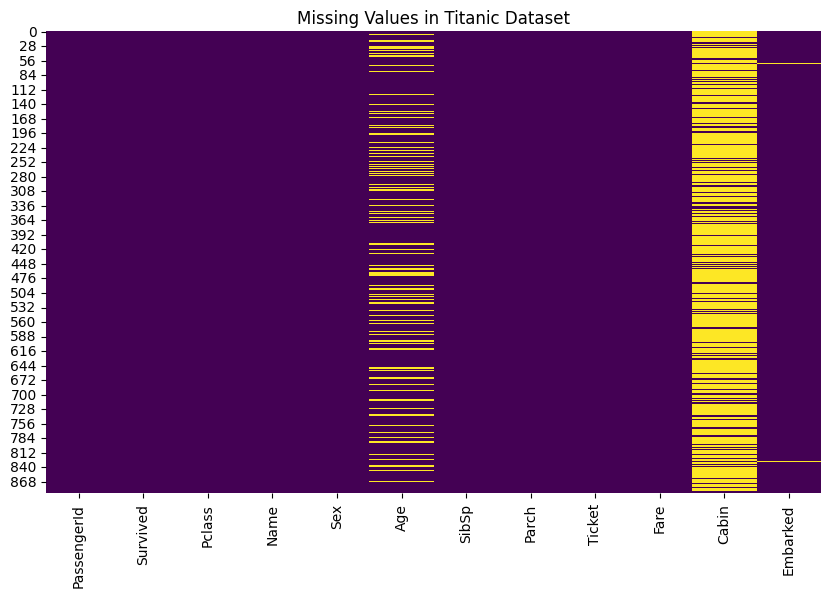

In [123]:
# Visualize missing values

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values in Titanic Dataset")
plt.show()

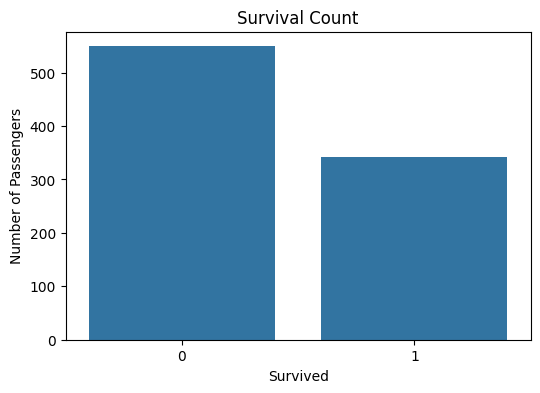

In [124]:
# Survival Count

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

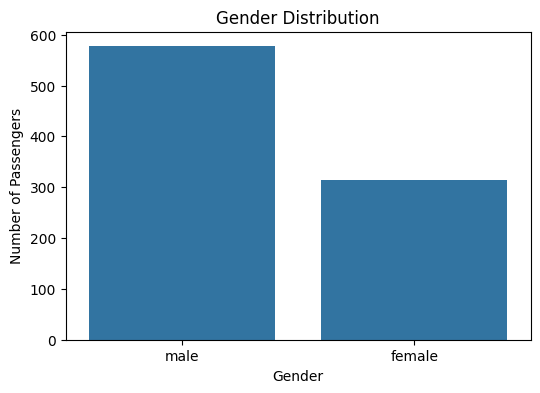

In [125]:
# Gender Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

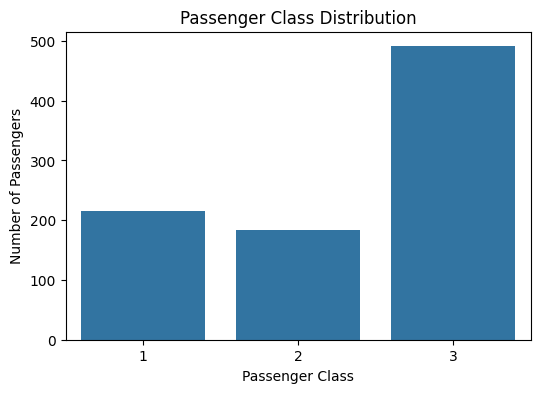

In [126]:
# Passenger Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

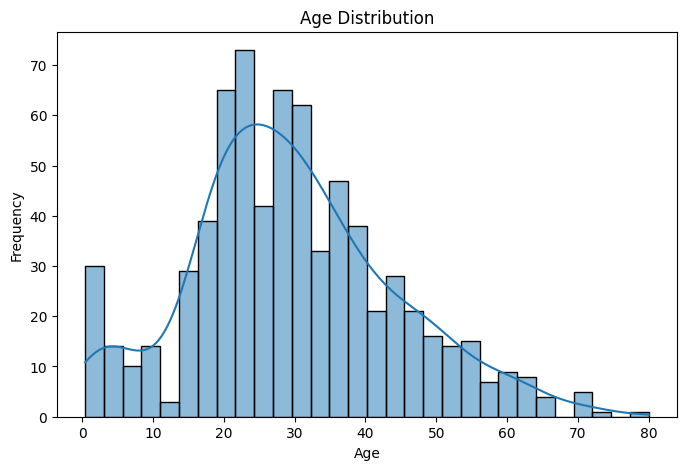

In [127]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

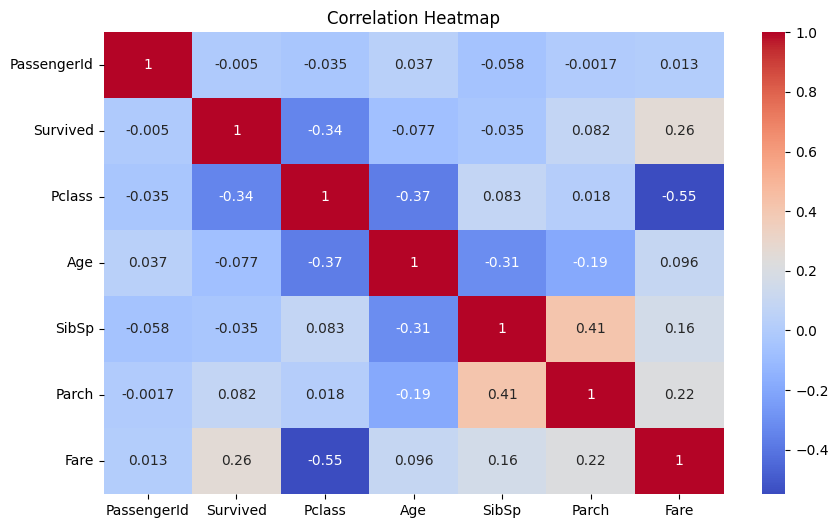

In [128]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# 5. Data Cleaning & Preprocessing

Data preprocessing is an important step in any machine learning project. It involves handling missing values, removing unnecessary features, and converting categorical data into numerical form so that machine learning algorithms can process the data effectively.

In this section, the Titanic dataset is cleaned and prepared for model building.

In [129]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [130]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [131]:
print(df["Age"].isnull().sum())
print(df["Embarked"].isnull().sum())

0
0


In [132]:
# Convert categorical columns into numerical values

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [133]:
print(df.columns)

print(df["Sex"].unique())

print(df["Embarked"].unique())

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
[0 1]
[0 1 2]


In [135]:
print(df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked  
0         A/5 21171   7.2500   NaN         0  
1          PC 17599  71.2833   C85         1  
2  STON/O2. 3101282   7.9250   NaN         0  
3            113803  53.1000  C123         0  
4            373450   8.0500   NaN         0  


In [138]:
print(df.columns)
print(df.isnull().sum())

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# 6. Feature Selection

Feature selection is the process of choosing the most relevant features for building a machine learning model. Unnecessary columns are removed to improve model performance and simplify the dataset.

For this project, PassengerId, Name, and Ticket are removed because they do not contribute significantly to predicting passenger survival.

In [139]:
# Remove unnecessary columns

df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# Display updated dataset
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [140]:
# Define input features (X) and target variable (y)

X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 7)
Target shape: (891,)


# 7. Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the machine learning model, while the testing data is used to evaluate its performance on unseen data.

In [141]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (712, 7)
Testing Features: (179, 7)
Training Target: (712,)
Testing Target: (179,)


# 8. Model Building

In this section, a Logistic Regression model is trained using the training dataset. Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems such as predicting whether a passenger survived or not.

In [142]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 9. Model Evaluation

After training the model, it is evaluated using the testing dataset. The model's predictions are compared with the actual values to measure its performance.

In [143]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [144]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7988826815642458


In [145]:
# Compare actual and predicted values

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred

results.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted
709,3,0,28.0,1,1,15.2458,1,1,0
439,2,0,31.0,0,0,10.5000,0,0,0
840,3,0,20.0,0,0,7.9250,0,0,0
720,2,1,6.0,0,1,33.0000,0,1,1
39,3,1,14.0,1,0,11.2417,1,1,1
290,1,1,26.0,0,0,78.8500,0,1,1
300,3,1,28.0,0,0,7.7500,2,1,1
333,3,0,16.0,2,0,18.0000,0,0,0
208,3,1,16.0,0,0,7.7500,2,1,1
136,1,1,19.0,0,2,26.2833,0,1,1


# 10. Results and Insights

The Logistic Regression model was successfully trained and tested on the Titanic dataset.

### Key Insights

- The dataset was cleaned by handling missing values and removing unnecessary columns.
- Categorical features were converted into numerical values.
- The dataset was divided into training and testing sets.
- Logistic Regression was used to predict passenger survival.
- The model achieved a good accuracy, showing that it can make reliable predictions on unseen data.

In [146]:
print("Model Evaluation Summary")
print("------------------------")
print("Algorithm Used: Logistic Regression")
print(f"Model Accuracy: {accuracy:.2f}")
print("The model successfully predicts passenger survival based on the given features.")

Model Evaluation Summary
------------------------
Algorithm Used: Logistic Regression
Model Accuracy: 0.80
The model successfully predicts passenger survival based on the given features.


# 11. Conclusion

In this project, an end-to-end machine learning workflow was completed using the Titanic dataset.

The project included:
- Loading the dataset
- Performing Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature selection
- Splitting the dataset
- Training a Logistic Regression model
- Evaluating the model
- Generating insights from the results

This project demonstrates the basic workflow of a machine learning classification problem using Python and Scikit-learn.